# 9.3.2 近似族与多峰中的初始化

## 学习目标与先修知识

用四状态（state）混合结构核对下界，比较局部解与完整联合后验（posterior）。

先修：9.3.1的KL与坐标更新，第5篇联合分布（distribution）和Bernoulli变量。

## 具体问题

两个细胞状态可能倾向于一起开启或一起关闭。每个细胞的边缘开启概率（probability）都是一半，是否足以认为它们独立？若近似只允许独立因子，多换初值（initial condition）能补回相关结构吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

比较两个同边缘但不同联合质量的分布。00、01、10、11依次排列。

In [2]:
joint=np.array([1.,math.exp(-4),math.exp(-4),1.]);joint/=joint.sum()
print("精确联合质量：",joint)
print("独立且边缘各一半：",[.25]*4)
print("精确边缘开启概率：",joint[2]+joint[3],joint[1]+joint[3])

精确联合质量： [0.4910069 0.0089931 0.0089931 0.4910069]
独立且边缘各一半： [0.25, 0.25, 0.25, 0.25]
精确边缘开启概率： 0.5 0.5


## 模型假设

z₁,z₂∈{0,1}代表两个教学细胞状态。给定观测（observation）后未归一化对数质量为[0,−J,−J,0]，J≥0，顺序固定为00、01、10、11。J 控制同向状态与异向状态之间的概率差。近似q由两个Bernoulli因子组成，参数（parameter）p₁、p₂是开启概率。

## 数学解释与推导

任意四状态分布有三个自由概率，而独立族只有p₁、p₂两个参数，质量为
$$q=[(1-p_1)(1-p_2),(1-p_1)p_2,p_1(1-p_2),p_1p_2].$$
在本目标中证据 $Z=2+2e^{-J}$，可以直接枚举；相关性缺失不是数值积分造成的。

记四个log联合质量为l₀₀、l₀₁、l₁₀、l₁₁。上一节的坐标最优式给出第一因子取1与取0的对数比
$$\mathrm{logit}(p_1)=(1-p_2)(l_{10}-l_{00})+p_2(l_{11}-l_{01}),$$
再用新p₁更新 $\mathrm{logit}(p_2)=(1-p_1)(l_{01}-l_{00})+p_1(l_{11}-l_{10})$。这里logit(p)=log[p/(1−p)]，其逆为sigmoid(x)=1/(1+e⁻ˣ)。两步是依次更新，不是同时替换。

独立族的下界可直接写成 $\sum_z q_zl_z-\sum_zq_z\log q_z$，零概率项按极限（limit）0log0=0处理。精确坐标最大化不会降低下界，但整个问题可能有不同局部解。J较大时，从偏00与偏11的初值可以得到对称的近似；从(.5,.5)开始则可能停留在对称固定点（fixed point），固定点并不自动是全局最优。

若改用完整四状态族，q=p可以令KL为0。若把两个独立解作混合，得到的也通常不再是原来的单个独立因子族；混合两个分布与先平均参数再构造一个分布，是不同的操作。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def discrete_elbo(log_joint,probabilities):
    bound=sum(q*(l-math.log(q)) for l,q in zip(log_joint,probabilities) if q>0)
    evidence=logsumexp(log_joint)
    return bound,evidence-bound


def discrete_mean_field(log_joint,initial,steps):
    p1,p2=initial;history=[]
    sigmoid=lambda x:1/(1+math.exp(-x))
    for _ in range(steps):
        p1=sigmoid((1-p2)*(log_joint[2]-log_joint[0])+p2*(log_joint[3]-log_joint[1]))
        p2=sigmoid((1-p1)*(log_joint[1]-log_joint[0])+p1*(log_joint[3]-log_joint[2]))
        q=[(1-p1)*(1-p2),(1-p1)*p2,p1*(1-p2),p1*p2]
        bound,gap=discrete_elbo(log_joint,q);history.append([p1,p2,bound,gap])
    return history

## 对照实验

固定J=4，比较三个初值下30轮更新。左图保留完整四状态概率，右图显示ELBO与可枚举的精确证据。

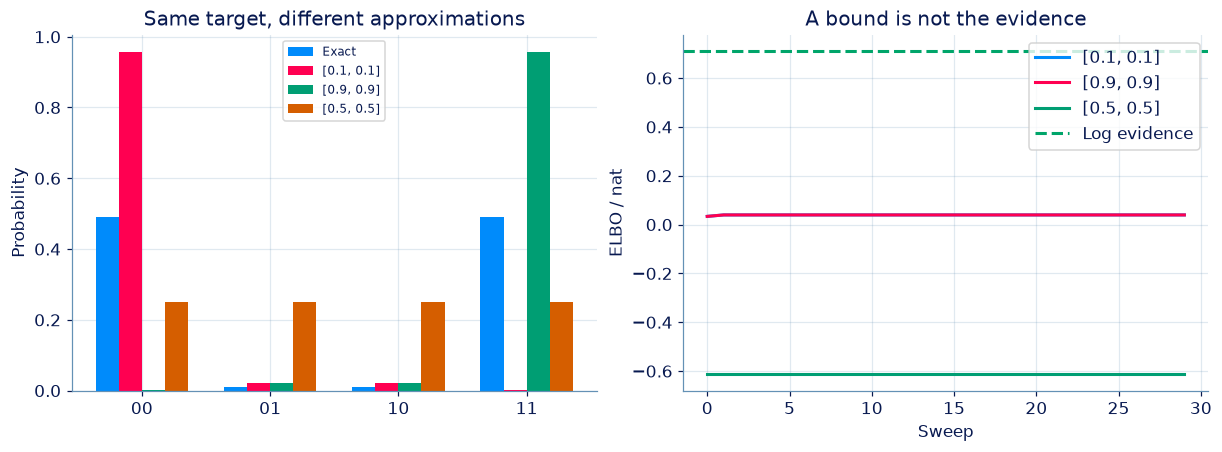

In [4]:
logs=[0.,-4.,-4.,0.];Z=2+2*math.exp(-4);target=np.exp(logs)/Z
fig,axes=plt.subplots(1,2,figsize=(11,4));x=np.arange(4);axes[0].bar(x-.27,target,width=.18,label='Exact')
histories=[]
for i,initial in enumerate([[.1,.1],[.9,.9],[.5,.5]]):
    history=np.array(discrete_mean_field(logs,initial,30));histories.append(history)
    p1,p2=history[-1,:2];q=[(1-p1)*(1-p2),(1-p1)*p2,p1*(1-p2),p1*p2]
    axes[0].bar(x-.09+i*.18,q,width=.18,label=str(initial));axes[1].plot(history[:,2],label=str(initial))
axes[0].set_xticks(x,['00','01','10','11']);axes[0].set(ylabel='Probability',title='Same target, different approximations');axes[0].legend(fontsize=8)
axes[1].axhline(math.log(Z),color=GREEN,linestyle='--',label='Log evidence');axes[1].set(xlabel='Sweep',ylabel='ELBO / nat',title='A bound is not the evidence');axes[1].legend();plt.show()

## 结果解释

对称初值的边缘概率正确，却给极少发生的01与10各分配四分之一质量。偏向某个峰的独立近似可能取得更高下界，但又遗漏另一峰。比较边缘均值、单个目标值或迭代是否停止，都不能替代对联合结构的检查。这一例不使用随机优化，因此不同结果来自初值与目标结构，而不是随机抽样误差。

### 独立核对

从四个显式联合概率（joint probability）独立计算KL，并检查两侧初值的标签对称、J=0的精确独立解与零轮返回。

In [5]:
for h in histories:
    assert np.min(np.diff(h[:,2]))>-1e-12
    p1,p2=h[-1,:2];q=np.array([(1-p1)*(1-p2),(1-p1)*p2,p1*(1-p2),p1*p2])
    np.testing.assert_allclose(h[-1,3],np.sum(q*np.log(q/target)),atol=1e-12)
np.testing.assert_allclose(histories[0][-1,:2]+histories[1][-1,:2],[1,1])
flat=discrete_mean_field([0,0,0,0],[0,1],1)[0]
np.testing.assert_allclose(flat,[.5,.5,math.log(4),0])
assert discrete_mean_field(logs,[.1,.1],0)==[]
print('直接枚举KL、单调性、对称与独立边界通过。')

直接枚举KL、单调性、对称与独立边界通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-03-变分推断/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在四个状态上检查近似

用独立Bernoulli因子近似给定二元联合分布（distribution），先更新第一个因子，再更新第二个。

**函数与代码模板**

```python
def solve(
    log_joint: list[float],
    initial: list[float],
    steps: int,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `log_joint` | `list[float]` | 按(0,0),(0,1),(1,0),(1,1)排列的log联合质量。 | 1 |
| `initial` | `list[float]` | 两个独立Bernoulli因子取1的初始概率（probability）。 | 1 |
| `steps` | `int` | 完整坐标扫描的次数。 | 次 |

**返回值**

直接返回 history（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 每轮[p1,p2,ELBO,证据差距]，不含初值（initial condition）；steps=0为空。 | 混合：概率与nat |

**计算规则**

logit(p1)=(1−p2)(l10−l00)+p2(l11−l01)；再以新p1计算logit(p2)=(1−p1)(l01−l00)+p1(l11−l10)。sigmoid(x)=1/(1+exp(−x))；q按题定顺序求下界与差距。

**约束与边界**

- log_joint长4且各值在[−20,20]；初始概率在[0,1]；0≤steps≤30。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| log_joint | 按(0,0),(0,1),(1,0),(1,1)排列的log联合质量。 | [0.0, -4.0, -4.0, 0.0] | 1 |
| initial | 两个独立Bernoulli因子取1的初始概率（probability）。 | [0.1, 0.1] | 1 |
| steps | 完整坐标扫描的次数。 | 2 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
log_joint = [0.0, -4.0, -4.0, 0.0]
initial = [0.1, 0.1]
steps = 2

result = solve(log_joint, initial, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 每轮[p1,p2,ELBO,证据差距]，不含初值（initial condition）；steps=0为空。 | [[0.039165722796764356, 0.024442773371647204, 0.03336721167089932, 0.6779298968068558], [0.02178606575243834, 0.021337693818330557, 0.039335424713921166, 0.6719616837638339]] | 混合：概率与nat |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.039165722796764356,
                    0.024442773371647204,
                    0.03336721167089932,
                    0.6779298968068558],
                   [0.02178606575243834,
                    0.021337693818330557,
                    0.039335424713921166,
                    0.6719616837638339]]
```

**样例解释**

第一轮的第一个logit为−3.2，p1≈.03917；第二个logit使用这个新p1。对称初值并不等于已经检查过所有局部解。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在四个状态上检查近似](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-discrete-coordinate)

### 第 2 题 · 多项选择题：两个因子能表示相关双峰吗

四状态（state）目标在00和11各约有一半质量，01和10极少。哪些判断正确？

- **A.** p1=p2=.5时独立族给四状态各1/4。
- **B.** 只要多迭代，独立族必能精确变成原目标。
- **C.** 允许完整四状态质量后可以直接归一化得到精确后验（posterior）。
- **D.** 应比较状态质量或相关性，不能只看两个边缘均值。

[作答：两个因子能表示相关双峰吗](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-two-modes-family)

### 第 3 题 · 单项选择题：从两侧开始的优化

对称双峰目标中，两种初始化分别收敛到偏00和偏11的近似，ELBO相同。哪项正确？

- **A.** 相同ELBO证明两个近似质量完全一致。
- **B.** 可能是对称的不同局部解，应报告初始化和被遗漏的模式。
- **C.** 必须删掉其中一个结果。
- **D.** 可以把两组因子概率（probability）逐元素平均后声称仍是最优解。

[作答：从两侧开始的优化](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-vi-initialization)

### 第 4 题 · 多项选择题：坐标更新为什么不下降

每次精确最大化一个因子的ELBO，另一个固定。哪些说法成立？

- **A.** 每步下界不下降。
- **B.** 必到全局最优。
- **C.** 数值稳定化和更新顺序仍需核对。
- **D.** 若换成近似更新，原单调性不再自动成立。

[作答：坐标更新为什么不下降](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-elbo-monotone)

### 第 5 题 · 单项选择题：Jensen等号在哪里

ELBO与证据的差为KL(q||p)。在所有有限状态（state）后验（posterior）概率（probability）均正时，何时达到等号？

- **A.** q只要选中概率最大的一个状态即可。
- **B.** q与后验逐状态一致。
- **C.** q的均值与后验均值一样即可。
- **D.** 任意归一化q都可以。

[作答：Jensen等号在哪里](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-jensen-support)

**进一步阅读**

[Blei 等，Variational Inference，v9](https://arxiv.org/html/1601.00670v9)：第2节的下界与坐标更新；本节数值为独立设计的教学小例子。